In [1]:
from langgraph.graph import MessagesState
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatMistralAI(model="mistral-small-2506")

In [4]:
# Define a custom state that extends MessagesState to include a running summary
class ChatState(MessagesState):
    summary: str

In [5]:
# Node to summarize the conversation when it gets too long
def summarize_conversation(state: ChatState):
    existing_summary = state["summary"]

    # Build summarization prompt, including the existing summary if there is one
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    # We ask the model to generate the summary based on the current messages
    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only the last 2 messages intact, and prepare to delete the rest
    messages_to_delete = state["messages"][:-2]

    # Return the new summary and a list of RemoveMessage commands to delete the old ones
    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
# The main chat node that interacts with the user
def chat_node(state: ChatState):
    messages = []

    # If a summary exists, provide it to the model as a system message so it remembers past context
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    # Append the recent un-summarized messages
    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
# Conditional function to decide if we need to summarize
def should_summarize(state: ChatState):
    # Trigger summarization if we have more than 6 messages in the state
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

# After the chat node, we check if we should summarize or end the turn
builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize", # If true, go to summarize node
        False: "__end__",  # If false, we are done
    }
)

# After summarizing, the turn ends
builder.add_edge("summarize", "__end__")

In [9]:
# Compile with an InMemorySaver to track the conversation and summary
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

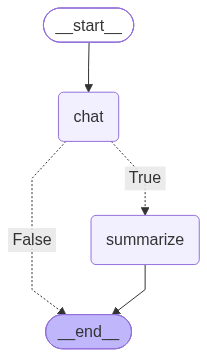

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

# Helper function to simulate a chat turn
def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:
# Helper function to display the current state of the graph (summary and messages)
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
# Turn 1
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='17b7b5d2-2b30-46b7-9937-44e239238681')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics (or quantum mechanics) is the branch of physics that studies the


In [15]:
# Turn 2
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='17b7b5d2-2b30-46b7-9937-44e239238681'), AIMessage(content='Quantum physics (or quantum mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles like electrons and photons. It describes a world that is fundamentally different from classical physics, where particles can behave like waves, and uncertainty plays a central role.\n\n### **Key Principles of Quantum Physics:**\n1. **Wave-Particle Duality**\n   - Particles (e.g., electrons, photons) exhibit both wave-like and particle-like properties.\n   - Example: Light behaves as a wave (interference patterns) but also as particles (photons).\n\n2. **Quantization**\n   - Certain properties (e.g., energy, angular momentum) are quantized—they can only take discrete values.\n   - Example: Electrons in an atom occupy specific energy levels.\n\n3. **Uncert

In [16]:
# Turn 3
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='17b7b5d2-2b30-46b7-9937-44e239238681'), AIMessage(content='Quantum physics (or quantum mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles like electrons and photons. It describes a world that is fundamentally different from classical physics, where particles can behave like waves, and uncertainty plays a central role.\n\n### **Key Principles of Quantum Physics:**\n1. **Wave-Particle Duality**\n   - Particles (e.g., electrons, photons) exhibit both wave-like and particle-like properties.\n   - Example: Light behaves as a wave (interference patterns) but also as particles (photons).\n\n2. **Quantization**\n   - Certain properties (e.g., energy, angular momentum) are quantized—they can only take discrete values.\n   - Example: Electrons in an atom occupy specific energy levels.\n\n3. **Uncert

In [17]:
# Turn 4
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='17b7b5d2-2b30-46b7-9937-44e239238681'), AIMessage(content='Quantum physics (or quantum mechanics) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles like electrons and photons. It describes a world that is fundamentally different from classical physics, where particles can behave like waves, and uncertainty plays a central role.\n\n### **Key Principles of Quantum Physics:**\n1. **Wave-Particle Duality**\n   - Particles (e.g., electrons, photons) exhibit both wave-like and particle-like properties.\n   - Example: Light behaves as a wave (interference patterns) but also as particles (photons).\n\n2. **Quantization**\n   - Certain properties (e.g., energy, angular momentum) are quantized—they can only take discrete values.\n   - Example: Electrons in an atom occupy specific energy levels.\n\n3. **Uncert